# TRE (Tertiärregelenergie) Bidding Analysis — Switzerland
### March 1–24, 2026 · 15-minute granularity

**Data source:** Swissgrid TRE auction results (`2026-03-TRE-Ergebnis.csv`)  
**Groups analysed:**
| Group | Direction | Underlying products |
|---|---|---|
| `Up` | Upward regulation | TRE_mFRR_da+, TRE_mFRR_sa+ |
| `Down` | Downward regulation | TRE_mFRR_da−, TRE_mFRR_sa− |

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white',
                     'axes.facecolor': '#f9f9f9', 'grid.alpha': 0.4})

PRODUCT_COLORS = {
    'Up':   '#2196F3',  # blue  – upward regulation
    'Down': '#F44336',  # red   – downward regulation
}
PRODUCT_ORDER = ['Up', 'Down']

DATA_PATH = r'TRL Data/2026-03-TRE-Ergebnis.csv'

## 1  Load & Pre-process

In [29]:
raw = pd.read_csv(
    DATA_PATH, sep=';', encoding='latin-1',
    usecols=[0, 1, 2, 3, 4, 6, 8, 10],
    names=['auction','from_time','to_time','product',
           'offered_mw','called_mw','price_eur','status'],
    header=0
)

# ── Parse date from auction code (e.g. TRE_26_03_02 → 2026-03-02) ──────────
def auction_to_date(s):
    parts = s.split('_')
    return pd.Timestamp(f'20{parts[1]}-{parts[2]}-{parts[3]}')

raw['date'] = raw['auction'].map(auction_to_date)

# ── Parse 15-min slot start time ─────────────────────────────────────────────
raw['datetime'] = raw['date'] + pd.to_timedelta(raw['from_time'] + ':00')
raw['hour'] = raw['datetime'].dt.hour
raw['slot'] = raw['datetime'].dt.hour * 4 + raw['datetime'].dt.minute // 15  # 0-95

# ── Filter March 1–24, keep main mFRR products ───────────────────────────────
MFRR_PRODUCTS = ['TRE_mFRR_da+', 'TRE_mFRR_da-', 'TRE_mFRR_sa+', 'TRE_mFRR_sa-']
df = raw[
    (raw['date'] >= '2026-03-01') &
    (raw['date'] <= '2026-03-24') &
    raw['product'].isin(MFRR_PRODUCTS)
].copy()

df['direction'] = df['product'].str.contains(r'\+').map({True: 'Upward', False: 'Downward'})
df['gate']      = df['product'].str.extract(r'_(da|sa)')[0].map({'da': 'Day-ahead', 'sa': 'Intraday'})
df['group']     = df['direction'].map({'Upward': 'Up', 'Downward': 'Down'})
df['activated'] = df['status'].str.lower().str.startswith('akt')

print(f"Rows (March 1–24): {len(df):,}")
print(f"Date range:        {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Groups:            {df['group'].unique().tolist()}")
print()
df[['product','group','offered_mw','called_mw','price_eur','status']].head(6)

Rows (March 1–24): 1,063,058
Date range:        2026-03-01 → 2026-03-24
Groups:            ['Up', 'Down']



,product,group,offered_mw,called_mw,price_eur,status
0,TRE_mFRR_da+,Up,27,0,114.0,verfügbar
1,TRE_mFRR_da+,Up,5,0,120.0,verfügbar
2,TRE_mFRR_da+,Up,5,0,120.3,verfügbar
3,TRE_mFRR_da+,Up,5,0,121.0,verfügbar
4,TRE_mFRR_da+,Up,5,0,122.3,verfügbar
5,TRE_mFRR_da+,Up,35,0,123.0,verfügbar


## 2  Summary Statistics

In [30]:
summary = (
    df.groupby('group')
    .agg(
        n_bids          = ('price_eur', 'count'),
        total_offered   = ('offered_mw', 'sum'),
        total_called    = ('called_mw', 'sum'),
        n_activated     = ('activated', 'sum'),
        price_min       = ('price_eur', 'min'),
        price_mean      = ('price_eur', 'mean'),
        price_median    = ('price_eur', 'median'),
        price_p90       = ('price_eur', lambda x: x.quantile(0.9)),
        price_max       = ('price_eur', 'max'),
        price_std       = ('price_eur', 'std'),
    )
    .reindex(PRODUCT_ORDER)
)
summary['activation_rate_%'] = (summary['n_activated'] / summary['n_bids'] * 100).round(1)
summary['volume_accepted_%'] = (summary['total_called'] / summary['total_offered'] * 100).round(1)

display_cols = {
    'n_bids': 'Bids',
    'n_activated': 'Activated',
    'activation_rate_%': 'Act.Rate %',
    'total_offered': 'Offered MW·h',
    'total_called': 'Called MW·h',
    'volume_accepted_%': 'Vol.Acc. %',
    'price_min': 'Price Min',
    'price_mean': 'Mean',
    'price_median': 'Median',
    'price_p90': 'P90',
    'price_max': 'Max',
    'price_std': 'Std Dev',
}
summary.rename(columns=display_cols)[list(display_cols.values())].style\
    .format({
        'Bids': '{:,.0f}', 'Activated': '{:,.0f}',
        'Offered MW·h': '{:,.0f}', 'Called MW·h': '{:,.0f}',
        'Price Min': '{:.1f}', 'Mean': '{:.1f}', 'Median': '{:.1f}',
        'P90': '{:.1f}', 'Max': '{:.1f}', 'Std Dev': '{:.1f}',
    })\
    .background_gradient(subset=['Act.Rate %', 'Vol.Acc. %'], cmap='YlOrRd')\
    .background_gradient(subset=['Mean', 'Median'], cmap='Blues')\
    .set_caption('TRE Bidding Summary — March 1–24, 2026')

,Bids,Activated,Act.Rate %,Offered MW·h,Called MW·h,Vol.Acc. %,Price Min,Mean,Median,P90,Max,Std Dev
group,,,,,,,,,,,,
Up,"623,530","8,072",1.300000,"5,834,305","109,646",1.900000,78.0,4636.9,1267.3,12807.3,15000.0,5151.9
Down,"439,528","2,918",0.700000,"3,692,889","43,585",1.200000,-15000.0,-5890.1,-5051.0,99.0,241.5,5543.5


## 3  Price Distribution by Product

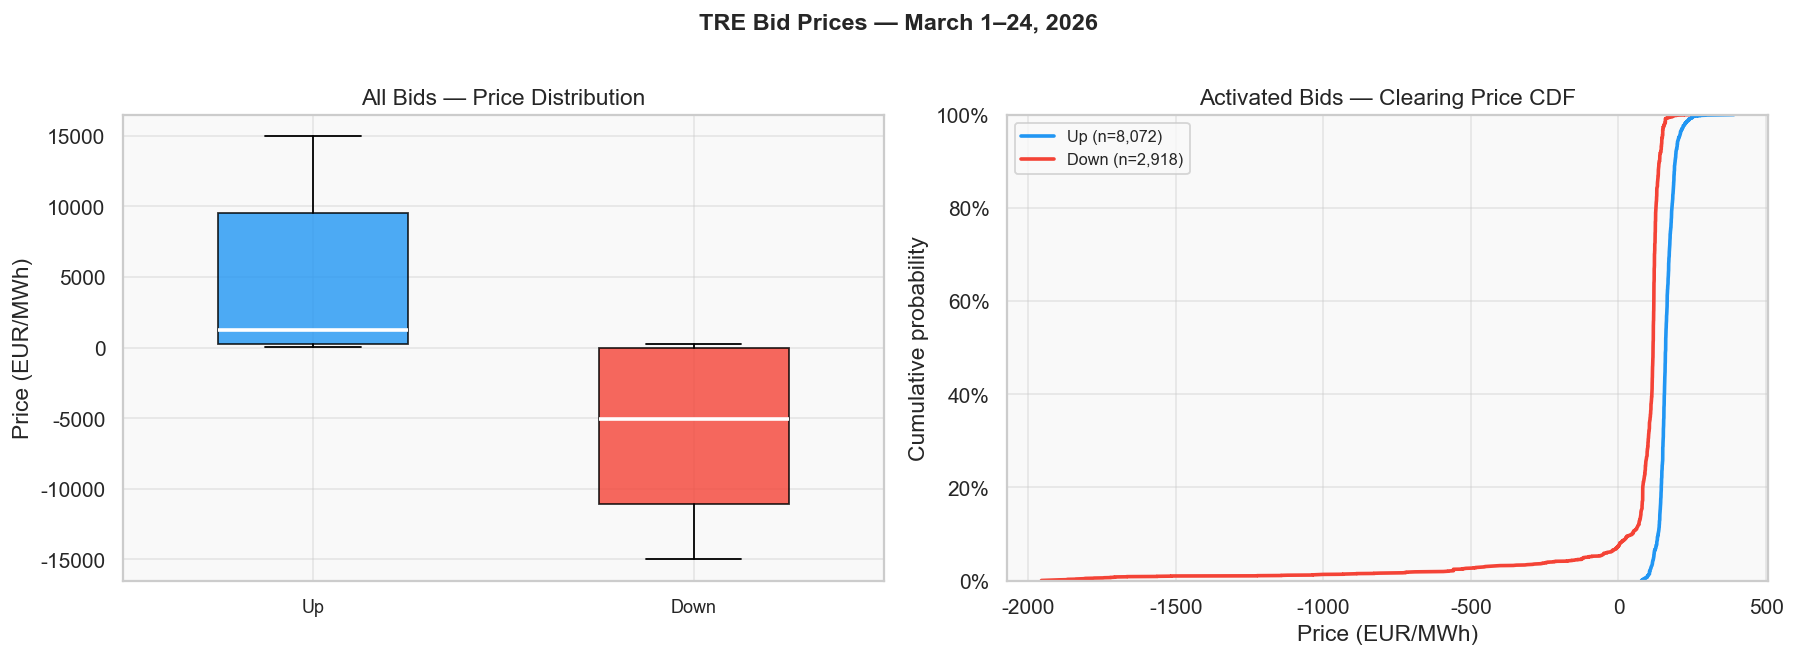

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Box plots all bids ──────────────────────────────────────────────────
ax = axes[0]
data_by_group = [df.loc[df['group'] == g, 'price_eur'].values for g in PRODUCT_ORDER]
bp = ax.boxplot(data_by_group, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
for patch, grp in zip(bp['boxes'], PRODUCT_ORDER):
    patch.set_facecolor(PRODUCT_COLORS[grp])
    patch.set_alpha(0.8)
ax.set_xticks(range(1, 3))
ax.set_xticklabels(PRODUCT_ORDER, fontsize=10)
ax.set_ylabel('Price (EUR/MWh)')
ax.set_title('All Bids — Price Distribution')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

# ── Right: CDF of activated bid prices ───────────────────────────────────────
ax = axes[1]
act_df = df[df['activated']]
for grp in PRODUCT_ORDER:
    prices = np.sort(act_df.loc[act_df['group'] == grp, 'price_eur'].values)
    if len(prices) == 0:
        continue
    cdf = np.arange(1, len(prices) + 1) / len(prices)
    ax.plot(prices, cdf, color=PRODUCT_COLORS[grp], lw=2,
            label=f"{grp} (n={len(prices):,})")

ax.set_xlabel('Price (EUR/MWh)')
ax.set_ylabel('Cumulative probability')
ax.set_title('Activated Bids — Clearing Price CDF')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

fig.suptitle('TRE Bid Prices — March 1–24, 2026', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

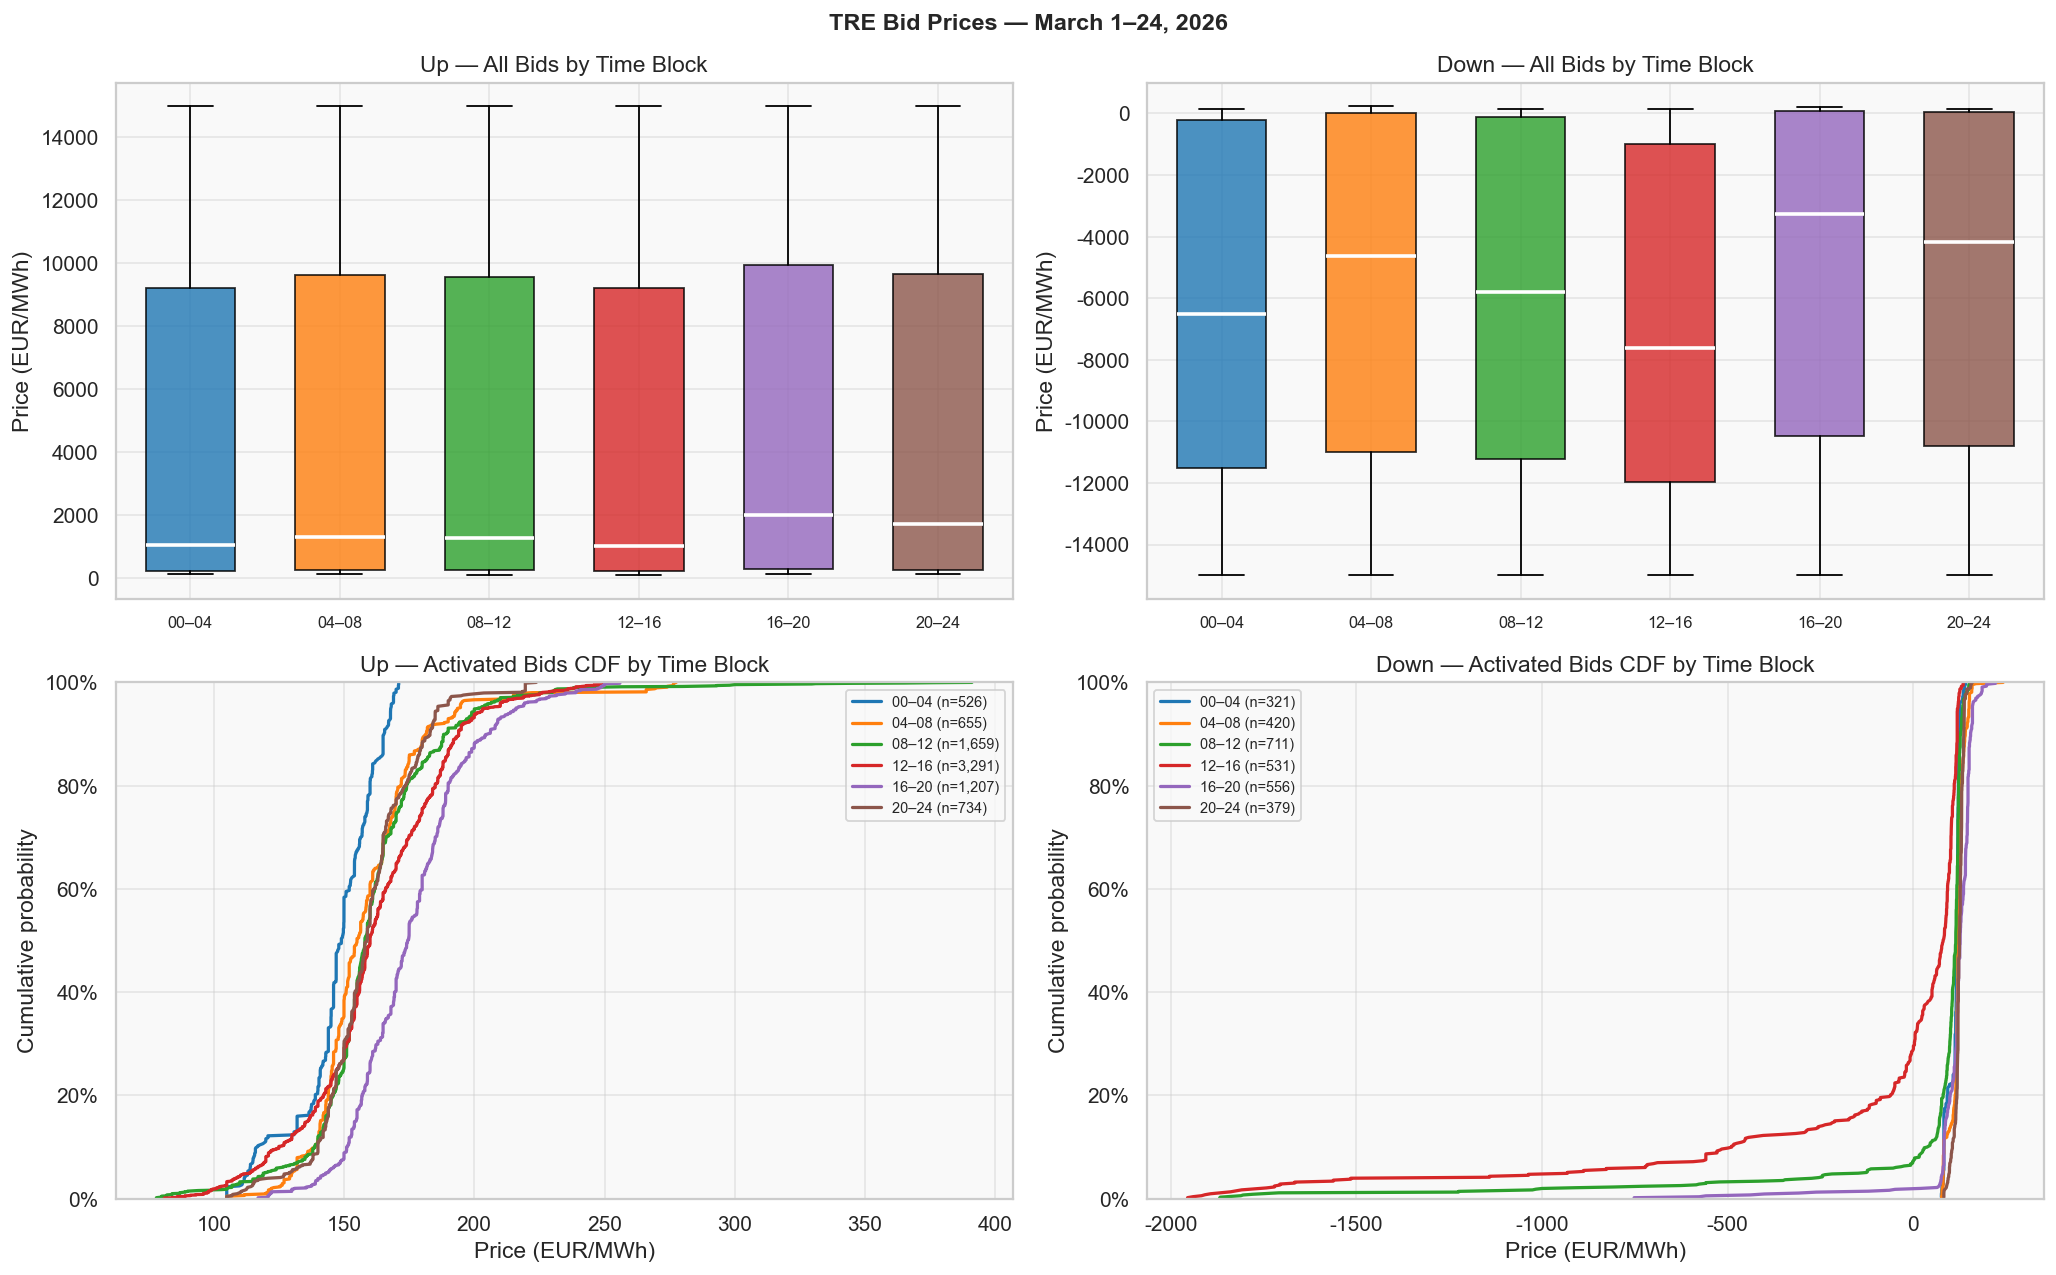

In [32]:
TIME_BLOCKS = [
    ('00–04',  0,  3),
    ('04–08',  4,  7),
    ('08–12',  8, 11),
    ('12–16', 12, 15),
    ('16–20', 16, 19),
    ('20–24', 20, 23),
]
BLOCK_COLORS = [plt.cm.tab10(i) for i in range(len(TIME_BLOCKS))]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, grp in enumerate(PRODUCT_ORDER):

    # ── Top row: box plot per time block ─────────────────────────────────────
    ax = axes[0, col]
    block_data = [
        df[df['hour'].between(h0, h1) & (df['group'] == grp)]['price_eur'].values
        for _, h0, h1 in TIME_BLOCKS
    ]
    bp = ax.boxplot(block_data, patch_artist=True, widths=0.6,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], BLOCK_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticks(range(1, len(TIME_BLOCKS) + 1))
    ax.set_xticklabels([lbl for lbl, _, _ in TIME_BLOCKS], fontsize=9)
    ax.set_ylabel('Price (EUR/MWh)')
    ax.set_title(f'{grp} — All Bids by Time Block')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

    # ── Bottom row: CDF per time block (activated bids) ───────────────────────
    ax = axes[1, col]
    for (lbl, h0, h1), color in zip(TIME_BLOCKS, BLOCK_COLORS):
        prices = np.sort(
            df[df['hour'].between(h0, h1) & df['activated'] & (df['group'] == grp)
               ]['price_eur'].values
        )
        if len(prices) == 0:
            continue
        cdf = np.arange(1, len(prices) + 1) / len(prices)
        ax.plot(prices, cdf, color=color, lw=1.8, label=f'{lbl} (n={len(prices):,})')
    ax.set_xlabel('Price (EUR/MWh)')
    ax.set_ylabel('Cumulative probability')
    ax.set_title(f'{grp} — Activated Bids CDF by Time Block')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
    ax.legend(fontsize=8)

fig.suptitle('TRE Bid Prices — March 1–24, 2026', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

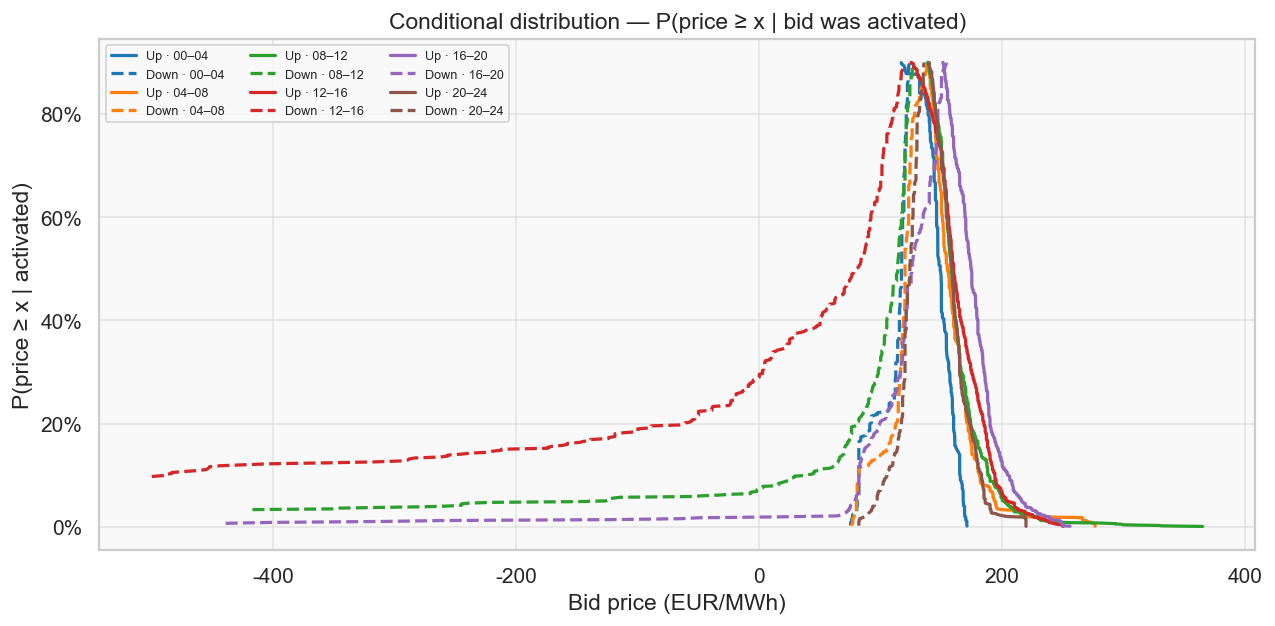

Group,Up,Down,Up,Down,Up,Down,Up,Down,Up,Down,Up,Down
Time block,00–04,00–04,04–08,04–08,08–12,08–12,12–16,12–16,16–20,16–20,20–24,20–24
Prob.,,,,,,,,,,,,
1%,170.9 €,76.1 €,271.5 €,77.0 €,238.4 €,-1660.5 €,239.0 €,-1858.5 €,248.7 €,-282.9 €,219.6 €,82.3 €
5%,168.0 €,80.9 €,193.9 €,80.3 €,201.6 €,-125.1 €,205.0 €,-910.0 €,216.0 €,78.9 €,186.0 €,97.1 €
10%,165.4 €,82.0 €,181.5 €,82.0 €,189.2 €,40.0 €,194.0 €,-489.3 €,205.2 €,82.2 €,183.0 €,105.0 €
20%,160.0 €,92.4 €,171.7 €,113.0 €,174.0 €,80.0 €,185.0 €,-61.0 €,190.0 €,99.2 €,173.7 €,117.1 €
30%,156.6 €,112.4 €,165.9 €,116.3 €,166.2 €,98.0 €,175.0 €,2.7 €,185.0 €,116.2 €,165.0 €,120.0 €
40%,152.0 €,115.4 €,160.0 €,118.7 €,161.9 €,105.0 €,166.0 €,50.0 €,180.0 €,120.0 €,161.9 €,121.0 €
50%,149.0 €,117.0 €,155.0 €,120.0 €,158.0 €,114.0 €,160.0 €,80.0 €,174.5 €,125.7 €,158.9 €,124.0 €
60%,146.0 €,118.7 €,150.8 €,123.0 €,154.9 €,117.0 €,155.9 €,92.0 €,169.5 €,135.0 €,154.3 €,126.6 €


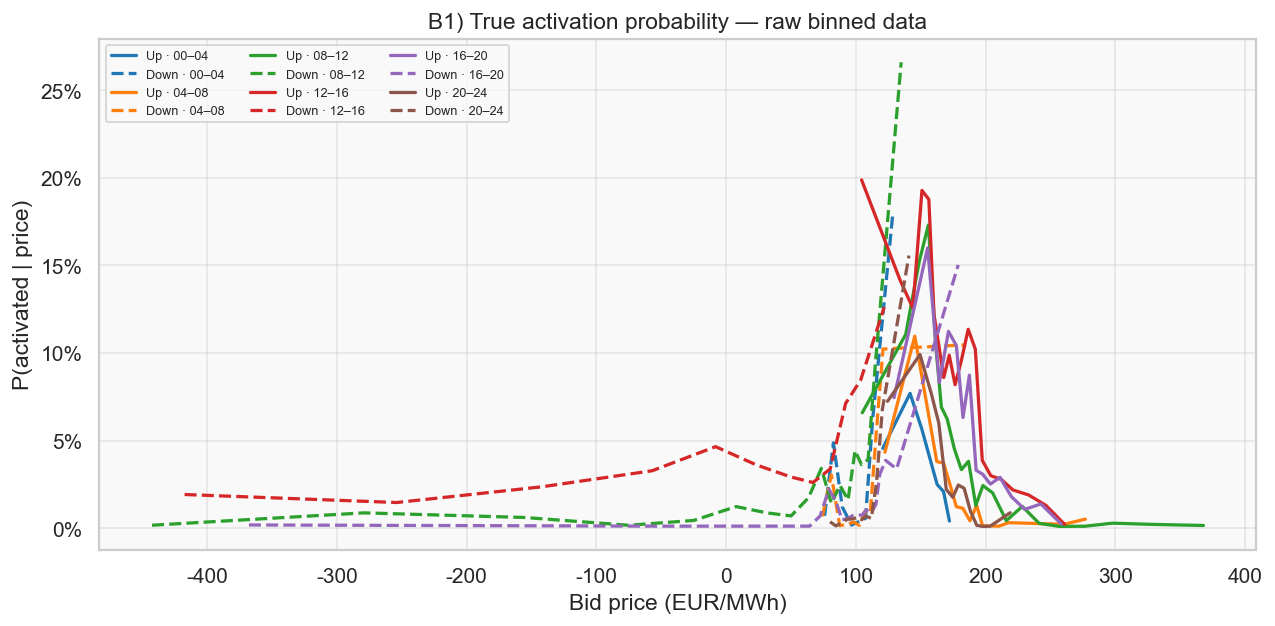

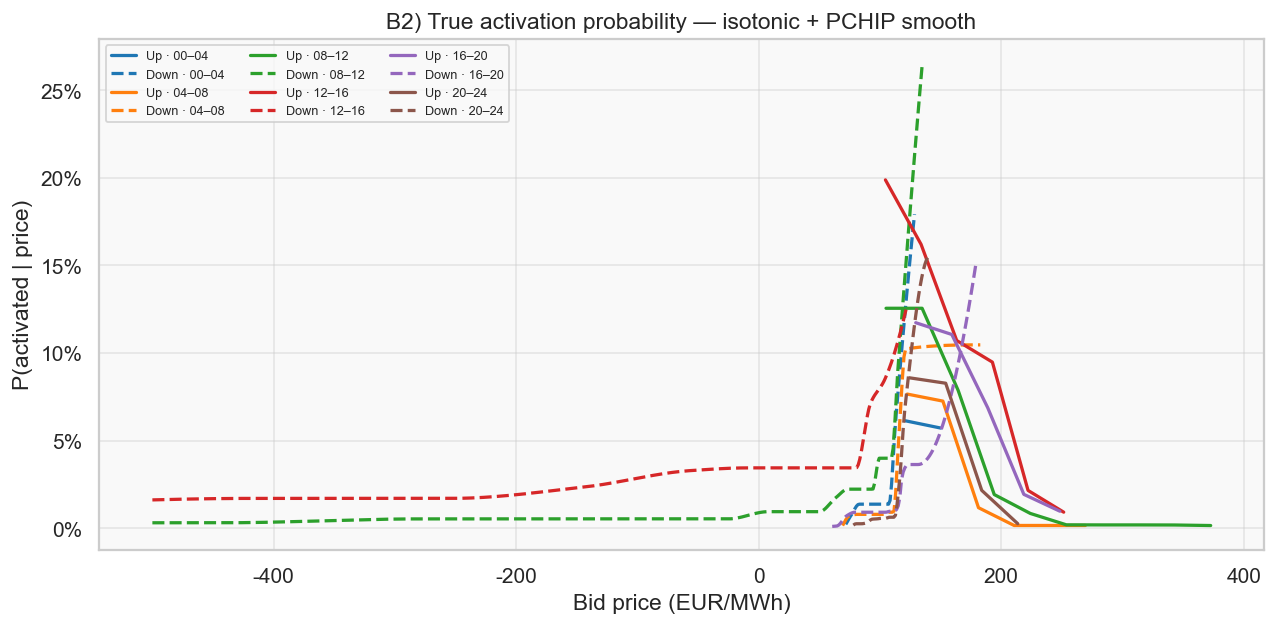

Group,Up,Down,Up,Down,Up,Down,Up,Down,Up,Down,Up,Down
Time block,00–04,00–04,04–08,04–08,08–12,08–12,12–16,12–16,16–20,16–20,20–24,20–24
Activation prob.,,,,,,,,,,,,
1%,172.1 €,78.5 €,188.5 €,111.7 €,216.4 €,52.7 €,251.3 €,-500.0 €,248.2 €,112.8 €,191.2 €,113.4 €
2.5%,164.8 €,109.6 €,173.8 €,113.4 €,194.1 €,95.3 €,214.6 €,-128.2 €,211.1 €,117.5 €,169.0 €,116.0 €
5.0%,150.2 €,111.8 €,159.2 €,115.5 €,171.8 €,111.5 €,nan €,86.2 €,nan €,147.1 €,nan €,118.6 €
7.5%,nan €,114.7 €,122.5 €,117.5 €,164.4 €,113.4 €,nan €,94.9 €,181.4 €,158.3 €,161.6 €,121.8 €
10.0%,nan €,117.8 €,nan €,120.2 €,nan €,115.9 €,170.6 €,112.0 €,166.6 €,166.4 €,nan €,125.6 €
12.5%,nan €,121.0 €,nan €,nan €,157.0 €,118.5 €,nan €,121.6 €,129.5 €,172.9 €,nan €,130.1 €
15.0%,nan €,124.4 €,nan €,nan €,nan €,121.3 €,nan €,nan €,nan €,179.0 €,nan €,136.8 €
17.5%,nan €,127.9 €,nan €,nan €,nan €,124.2 €,119.2 €,nan €,nan €,nan €,nan €,nan €


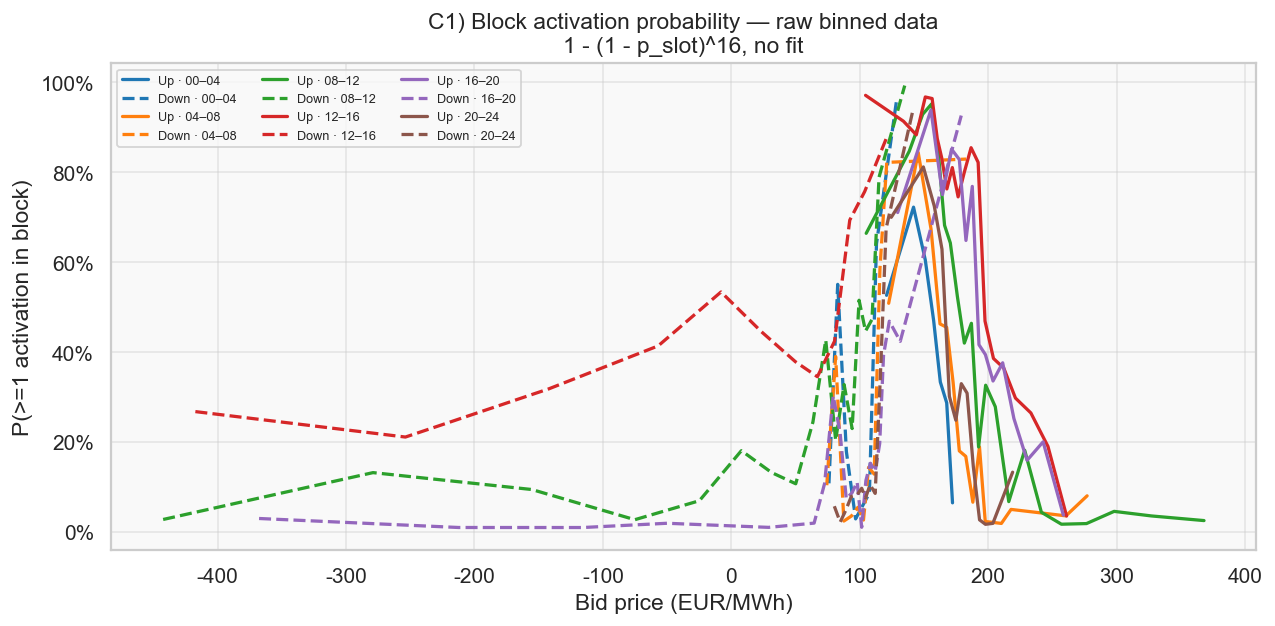

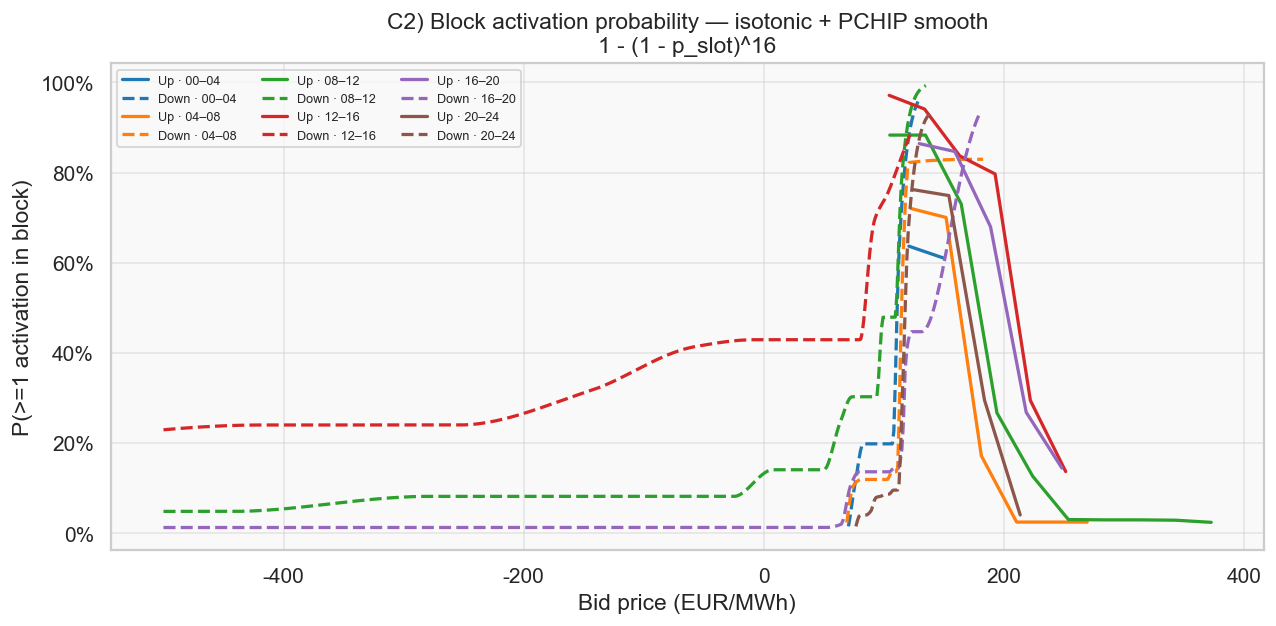

Group,Up,Down,Up,Down,Up,Down,Up,Down,Up,Down,Up,Down
Time block,00–04,00–04,04–08,04–08,08–12,08–12,12–16,12–16,16–20,16–20,20–24,20–24
Block act. prob.,,,,,,,,,,,,
10%,nan €,75.4 €,nan €,73.8 €,231.2 €,-13.0 €,nan €,nan €,nan €,71.7 €,nan €,112.5 €
20%,nan €,107.7 €,nan €,112.4 €,nan €,58.4 €,244.0 €,nan €,225.9 €,115.5 €,nan €,114.1 €
30%,164.8 €,109.3 €,173.8 €,113.1 €,nan €,71.8 €,221.9 €,-162.4 €,nan €,116.8 €,176.4 €,115.3 €
40%,nan €,110.3 €,nan €,113.7 €,nan €,96.9 €,nan €,-75.6 €,196.3 €,118.9 €,nan €,116.6 €
50%,nan €,111.2 €,nan €,114.8 €,nan €,110.2 €,nan €,84.3 €,nan €,142.0 €,nan €,117.9 €
60%,150.2 €,112.5 €,nan €,115.8 €,nan €,111.8 €,nan €,87.4 €,nan €,150.1 €,nan €,119.2 €
70%,nan €,114.4 €,151.8 €,117.5 €,nan €,113.4 €,nan €,93.0 €,188.8 €,157.3 €,161.6 €,121.1 €
80%,nan €,117.2 €,nan €,119.6 €,nan €,115.3 €,192.6 €,110.1 €,166.6 €,165.1 €,nan €,125.0 €


In [33]:
from sklearn.isotonic import IsotonicRegression
from scipy.interpolate import PchipInterpolator

BLOCK_LS = {'Up': '-', 'Down': '--'}

# ════════════════════════════════════════════════════════════════════════════
# A) CONDITIONAL DISTRIBUTION — P(price ≥ x | activated)
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
for (lbl, h0, h1), color in zip(TIME_BLOCKS, BLOCK_COLORS):
    act = df[df['hour'].between(h0, h1) & df['activated']]
    for grp in PRODUCT_ORDER:
        prices = np.sort(act.loc[act['group'] == grp, 'price_eur'].values)
        if len(prices) == 0:
            continue
        cdf      = np.arange(1, len(prices) + 1) / len(prices)
        act_prob = cdf if grp == 'Down' else 1 - cdf
        mask     = (act_prob >= 0.001) & (act_prob <= 0.90) & (prices >= -500)
        ax.plot(prices[mask], act_prob[mask],
                color=color, ls=BLOCK_LS[grp], lw=1.8, label=f'{grp} · {lbl}')
ax.set_xlabel('Bid price (EUR/MWh)')
ax.set_ylabel('P(price ≥ x | activated)')
ax.set_title('Conditional distribution — P(price ≥ x | bid was activated)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

# Percentile table A
act_probs_cond = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99]
cols_cond = {}
for lbl, h0, h1 in TIME_BLOCKS:
    act = df[df['hour'].between(h0, h1) & df['activated']]
    for grp in PRODUCT_ORDER:
        prices = act.loc[act['group'] == grp, 'price_eur']
        cols_cond[(grp, lbl)] = (
            [round(float(np.percentile(prices, p if grp == 'Down' else 100 - p)), 1)
             for p in act_probs_cond]
            if not prices.empty else [None] * len(act_probs_cond)
        )
cond_df = pd.DataFrame(cols_cond, index=[f'{p}%' for p in act_probs_cond])
cond_df.index.name = 'Prob.'
cond_df.columns = pd.MultiIndex.from_tuples(cond_df.columns, names=['Group', 'Time block'])
display(
    cond_df.style.format('{:.1f} €')
    .background_gradient(cmap='RdYlGn', axis=None)
    .set_caption('A) Conditional — price (EUR/MWh) at Xth percentile of activated bids')
)


# ════════════════════════════════════════════════════════════════════════════
# B1) TRUE ACTIVATION PROBABILITY — raw binned data, no fit
# ════════════════════════════════════════════════════════════════════════════
def activation_prob_raw(grp_df, grp, n_bins=60):
    sub = grp_df[grp_df['group'] == grp].copy()
    sub['price_bin'], _ = pd.qcut(sub['price_eur'], q=n_bins, retbins=True, duplicates='drop')
    rates   = sub.groupby('price_bin', observed=True)['activated'].mean()
    centers = np.array([(iv.left + iv.right) / 2 for iv in rates.index])
    return centers, rates.values

fig, ax = plt.subplots(figsize=(10, 5))
for (lbl, h0, h1), color in zip(TIME_BLOCKS, BLOCK_COLORS):
    block_df = df[df['hour'].between(h0, h1)]
    for grp in PRODUCT_ORDER:
        centers, rates = activation_prob_raw(block_df, grp)
        mask = (centers >= -500) & (rates >= 0.001) & (rates <= 0.90)
        if mask.sum() < 2:
            continue
        ax.plot(centers[mask], rates[mask],
                color=color, ls=BLOCK_LS[grp], lw=1.8, label=f'{grp} · {lbl}')
ax.set_xlabel('Bid price (EUR/MWh)')
ax.set_ylabel('P(activated | price)')
ax.set_title('B1) True activation probability — raw binned data')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# B2) TRUE ACTIVATION PROBABILITY — isotonic + PCHIP smooth
# ════════════════════════════════════════════════════════════════════════════
def fit_smooth(grp_df, grp, n_bins=60):
    sub = grp_df[grp_df['group'] == grp].copy()
    sub['price_bin'], _ = pd.qcut(sub['price_eur'], q=n_bins, retbins=True, duplicates='drop')
    rates   = sub.groupby('price_bin', observed=True)['activated'].mean()
    centers = np.array([(iv.left + iv.right) / 2 for iv in rates.index])
    iso     = IsotonicRegression(increasing=(grp == 'Down'), out_of_bounds='clip')
    mono    = iso.fit_transform(centers, rates.values)
    return PchipInterpolator(centers, mono, extrapolate=True), centers

def price_at_prob_smooth(interp, target_prob, price_min, price_max, n=2000):
    grid  = np.linspace(price_min, price_max, n)
    probs = np.clip(interp(grid), 0, 1)
    diffs = np.abs(probs - target_prob)
    idx   = np.argmin(diffs)
    if diffs[idx] > 0.01:
        return None
    return round(float(grid[idx]), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for (lbl, h0, h1), color in zip(TIME_BLOCKS, BLOCK_COLORS):
    block_df = df[df['hour'].between(h0, h1)]
    for grp in PRODUCT_ORDER:
        sub = block_df[block_df['group'] == grp]['price_eur']
        if len(sub) < 10:
            continue
        interp, centers = fit_smooth(block_df, grp)
        price_grid = np.linspace(max(centers.min(), -500), centers.max(), 500)
        probs      = np.clip(interp(price_grid), 0, 1)
        mask       = (probs >= 0.001) & (probs <= 0.90)
        if mask.sum() < 2:
            continue
        ax.plot(price_grid[mask], probs[mask],
                color=color, ls=BLOCK_LS[grp], lw=1.8, label=f'{grp} · {lbl}')
ax.set_xlabel('Bid price (EUR/MWh)')
ax.set_ylabel('P(activated | price)')
ax.set_title('B2) True activation probability — isotonic + PCHIP smooth')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

# Table B2
act_probs_true = [1] + [round(p, 1) for p in np.arange(2.5, 20.1, 2.5)]
cols_true = {}
for lbl, h0, h1 in TIME_BLOCKS:
    block_df = df[df['hour'].between(h0, h1)]
    for grp in PRODUCT_ORDER:
        sub = block_df[block_df['group'] == grp]['price_eur']
        if len(sub) < 10:
            cols_true[(grp, lbl)] = [None] * len(act_probs_true)
            continue
        interp, centers = fit_smooth(block_df, grp)
        pmin = max(float(centers.min()), -500)
        pmax = float(centers.max())
        cols_true[(grp, lbl)] = [
            price_at_prob_smooth(interp, p / 100, pmin, pmax)
            for p in act_probs_true
        ]

true_df = pd.DataFrame(cols_true, index=[f'{p}%' for p in act_probs_true])
true_df.index.name = 'Activation prob.'
true_df.columns = pd.MultiIndex.from_tuples(true_df.columns, names=['Group', 'Time block'])
display(
    true_df.style
    .format(lambda v: f'{v:.1f} €' if v is not None else '–')
    .background_gradient(cmap='RdYlGn', axis=None)
    .set_caption('B2) True — bid price (EUR/MWh) at which P(activated | price) = X%, isotonic + PCHIP')
)


# ════════════════════════════════════════════════════════════════════════════
# C1) BLOCK ACTIVATION PROBABILITY — raw binned data
#     P(>=1 activation in block) = 1 - (1 - p_slot)^16, raw per-slot rates
# ════════════════════════════════════════════════════════════════════════════
N_SLOTS = 16  # 16 x 15-min slots per 4-hour block

fig, ax = plt.subplots(figsize=(10, 5))
for (lbl, h0, h1), color in zip(TIME_BLOCKS, BLOCK_COLORS):
    block_df = df[df['hour'].between(h0, h1)]
    for grp in PRODUCT_ORDER:
        centers, slot_rates = activation_prob_raw(block_df, grp)
        block_rates = 1 - (1 - slot_rates) ** N_SLOTS
        mask = (centers >= -500) & (block_rates >= 0.01) & (block_rates <= 0.999)
        if mask.sum() < 2:
            continue
        ax.plot(centers[mask], block_rates[mask],
                color=color, ls=BLOCK_LS[grp], lw=1.8, label=f'{grp} · {lbl}')
ax.set_xlabel('Bid price (EUR/MWh)')
ax.set_ylabel('P(>=1 activation in block)')
ax.set_title('C1) Block activation probability — raw binned data\n1 - (1 - p_slot)^16, no fit')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════════════════════
# C2) BLOCK ACTIVATION PROBABILITY — isotonic + PCHIP smooth
# ════════════════════════════════════════════════════════════════════════════
def price_at_block_prob(interp, centers, target_block_prob, n=2000):
    pmin = max(float(centers.min()), -500)
    pmax = float(centers.max())
    grid        = np.linspace(pmin, pmax, n)
    slot_probs  = np.clip(interp(grid), 0, 1)
    block_probs = 1 - (1 - slot_probs) ** N_SLOTS
    diffs = np.abs(block_probs - target_block_prob)
    idx   = np.argmin(diffs)
    if diffs[idx] > 0.02:
        return None
    return round(float(grid[idx]), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for (lbl, h0, h1), color in zip(TIME_BLOCKS, BLOCK_COLORS):
    blk_df = df[df['hour'].between(h0, h1)]
    for grp in PRODUCT_ORDER:
        sub = blk_df[blk_df['group'] == grp]['price_eur']
        if len(sub) < 10:
            continue
        interp, centers = fit_smooth(blk_df, grp)
        price_grid  = np.linspace(max(centers.min(), -500), centers.max(), 500)
        slot_probs  = np.clip(interp(price_grid), 0, 1)
        block_probs = 1 - (1 - slot_probs) ** N_SLOTS
        mask = (block_probs >= 0.01) & (block_probs <= 0.999)
        if mask.sum() < 2:
            continue
        ax.plot(price_grid[mask], block_probs[mask],
                color=color, ls=BLOCK_LS[grp], lw=1.8, label=f'{grp} · {lbl}')
ax.set_xlabel('Bid price (EUR/MWh)')
ax.set_ylabel('P(>=1 activation in block)')
ax.set_title('C2) Block activation probability — isotonic + PCHIP smooth\n1 - (1 - p_slot)^16')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

# Table C2
block_prob_targets = [10, 20, 30, 40, 50, 60, 70, 80, 90]
cols_block = {}
for lbl, h0, h1 in TIME_BLOCKS:
    blk_df = df[df['hour'].between(h0, h1)]
    for grp in PRODUCT_ORDER:
        sub = blk_df[blk_df['group'] == grp]['price_eur']
        if len(sub) < 10:
            cols_block[(grp, lbl)] = [None] * len(block_prob_targets)
            continue
        interp, centers = fit_smooth(blk_df, grp)
        cols_block[(grp, lbl)] = [
            price_at_block_prob(interp, centers, p / 100)
            for p in block_prob_targets
        ]

block_tbl = pd.DataFrame(cols_block, index=[f'{p}%' for p in block_prob_targets])
block_tbl.index.name = 'Block act. prob.'
block_tbl.columns = pd.MultiIndex.from_tuples(block_tbl.columns, names=['Group', 'Time block'])
display(
    block_tbl.style
    .format(lambda v: f'{v:.1f} €' if v is not None else '–')
    .background_gradient(cmap='RdYlGn', axis=None)
    .set_caption('C2) Block probability — bid price (EUR/MWh) to achieve P(>=1 activation in 4h block) = X%  (assumes 16 independent slots; 1-(1-p_slot)^16)')
)

C:\Users\ThijsAntoniedeBoer\AppData\Local\Temp\ipykernel_3676\59192651.py:73: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\ThijsAntoniedeBoer\OneDrive - HELION\Dokumente\python-projects\standard_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


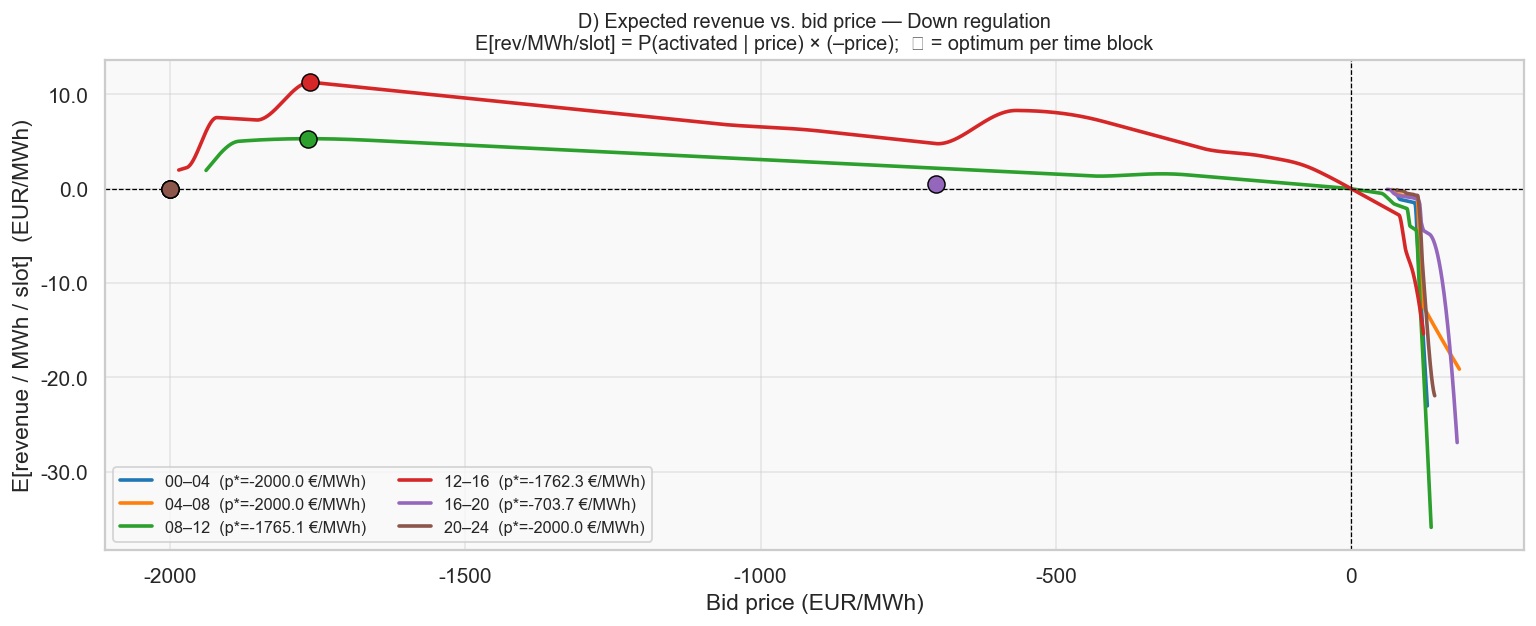

,Optimal bid (EUR/MWh),P(activation),E[rev] / MWh / slot (€),E[rev] / MWh / block (€)
Time block,,,,
00–04,-2000.0 €,0.0 %,0.00 €,0.00 €
04–08,-2000.0 €,0.0 %,0.00 €,0.00 €
08–12,-1765.1 €,0.3 %,5.31 €,85.01 €
12–16,-1762.3 €,0.6 %,11.30 €,180.80 €
16–20,-703.7 €,0.1 %,0.50 €,7.95 €
20–24,-2000.0 €,0.0 %,0.00 €,0.00 €


In [44]:
# ════════════════════════════════════════════════════════════════════════════
# D) OPTIMAL BID PRICE — maximise expected revenue for Down regulation
#
#   For down regulation the TSO activates highest prices first, so:
#     • higher bid price → higher P(activation)
#     • more negative bid price → higher revenue per activation
#       (revenue ≈ –price  when price < 0, i.e. charging at a discount)
#
#   Objective (per slot, per MWh offered):
#       E[rev](p) = P(activated | price = p) × (–p)
#
#   We sweep the price grid from the PCHIP fit (B2) and find p* = argmax.
#   The 4-hour window contains 16 slots; assuming the same bid for each slot
#   and independent activations:
#       E[rev per block / MWh] = 16 × E[rev per slot / MWh]
# ════════════════════════════════════════════════════════════════════════════

N_SLOTS = 16   # 16 × 15-min slots per 4-hour block
N_GRID  = 5000

fig, ax = plt.subplots(figsize=(12, 5))

rows = []
for (lbl, h0, h1), color in zip(TIME_BLOCKS, BLOCK_COLORS):
    block_df = df[df['hour'].between(h0, h1)]
    sub = block_df[block_df['group'] == 'Down']['price_eur']
    if len(sub) < 10:
        continue

    interp, centers = fit_smooth(block_df, 'Down')
    pmin = max(float(centers.min()), -2000)
    pmax = float(centers.max())

    price_grid  = np.linspace(pmin, pmax, N_GRID)
    slot_prob   = np.clip(interp(price_grid), 0, 1)
    exp_rev     = slot_prob * (-price_grid)          # E[rev/MWh/slot]

    opt_idx = int(np.argmax(exp_rev))
    p_opt   = price_grid[opt_idx]
    prob_at_opt = slot_prob[opt_idx]
    rev_slot    = exp_rev[opt_idx]
    rev_block   = N_SLOTS * rev_slot

    # Plot curve
    mask = slot_prob > 0.001
    ax.plot(price_grid[mask], exp_rev[mask],
            color=color, lw=2, label=f'{lbl}  (p*={p_opt:.1f} €/MWh)')

    # Mark optimum
    ax.scatter([p_opt], [rev_slot], color=color, s=90, zorder=5,
               edgecolors='black', linewidths=0.8)

    rows.append({
        'Time block':              lbl,
        'Optimal bid (EUR/MWh)':  round(p_opt, 1),
        'P(activation)':          round(prob_at_opt * 100, 1),
        'E[rev] / MWh / slot (€)': round(rev_slot, 2),
        'E[rev] / MWh / block (€)': round(rev_block, 2),
    })

ax.axhline(0, color='black', lw=0.7, ls='--')
ax.axvline(0, color='black', lw=0.7, ls='--')
ax.set_xlabel('Bid price (EUR/MWh)')
ax.set_ylabel('E[revenue / MWh / slot]  (EUR/MWh)')
ax.set_title(
    'D) Expected revenue vs. bid price — Down regulation\n'
    'E[rev/MWh/slot] = P(activated | price) × (–price);  ★ = optimum per time block',
    fontsize=11
)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

opt_df = pd.DataFrame(rows).set_index('Time block')
display(
    opt_df.style
    .format({
        'Optimal bid (EUR/MWh)':     '{:.1f} €',
        'P(activation)':              '{:.1f} %',
        'E[rev] / MWh / slot (€)':   '{:.2f} €',
        'E[rev] / MWh / block (€)':  '{:.2f} €',
    })
    .background_gradient(cmap='YlGn', subset=['E[rev] / MWh / slot (€)', 'E[rev] / MWh / block (€)'])
    .background_gradient(cmap='RdYlGn_r', subset=['Optimal bid (EUR/MWh)'])
    .background_gradient(cmap='Blues', subset=['P(activation)'])
    .set_caption(
        'D) Optimal Down-regulation bid per 4-hour block — maximises E[revenue/MWh/slot]\n'
        'Assumption: same bid price across all 16 slots; revenue = –price when activated'
    )
)


## 4  Price Histograms — All vs. Activated Bids

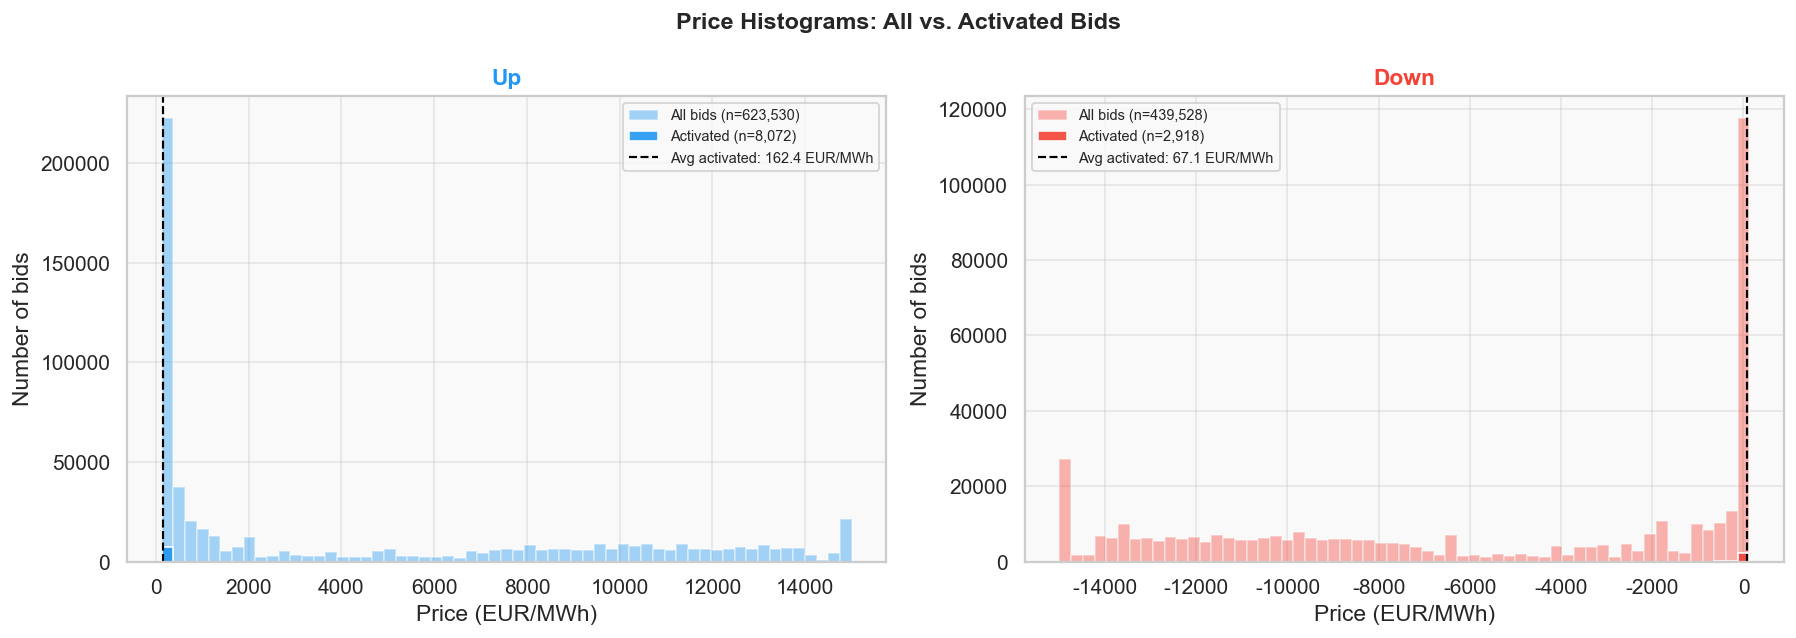

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grp in zip(axes, PRODUCT_ORDER):
    all_prices = df.loc[df['group'] == grp, 'price_eur']
    act_prices = df.loc[(df['group'] == grp) & df['activated'], 'price_eur']

    bins = np.linspace(all_prices.quantile(0.01), all_prices.quantile(0.99), 60)
    ax.hist(all_prices, bins=bins, color=PRODUCT_COLORS[grp], alpha=0.4,
            label=f'All bids (n={len(all_prices):,})')
    if len(act_prices) > 0:
        ax.hist(act_prices, bins=bins, color=PRODUCT_COLORS[grp], alpha=0.9,
                label=f'Activated (n={len(act_prices):,})')
        ax.axvline(act_prices.mean(), color='black', ls='--', lw=1.2,
                   label=f'Avg activated: {act_prices.mean():.1f} EUR/MWh')

    ax.set_title(grp, fontweight='bold', color=PRODUCT_COLORS[grp])
    ax.set_xlabel('Price (EUR/MWh)')
    ax.set_ylabel('Number of bids')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

fig.suptitle('Price Histograms: All vs. Activated Bids', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5  Marginal Clearing Price Over Time

For each 15-minute interval, the **marginal price** is the highest price among all activated bids — the price that 'clears' the market.

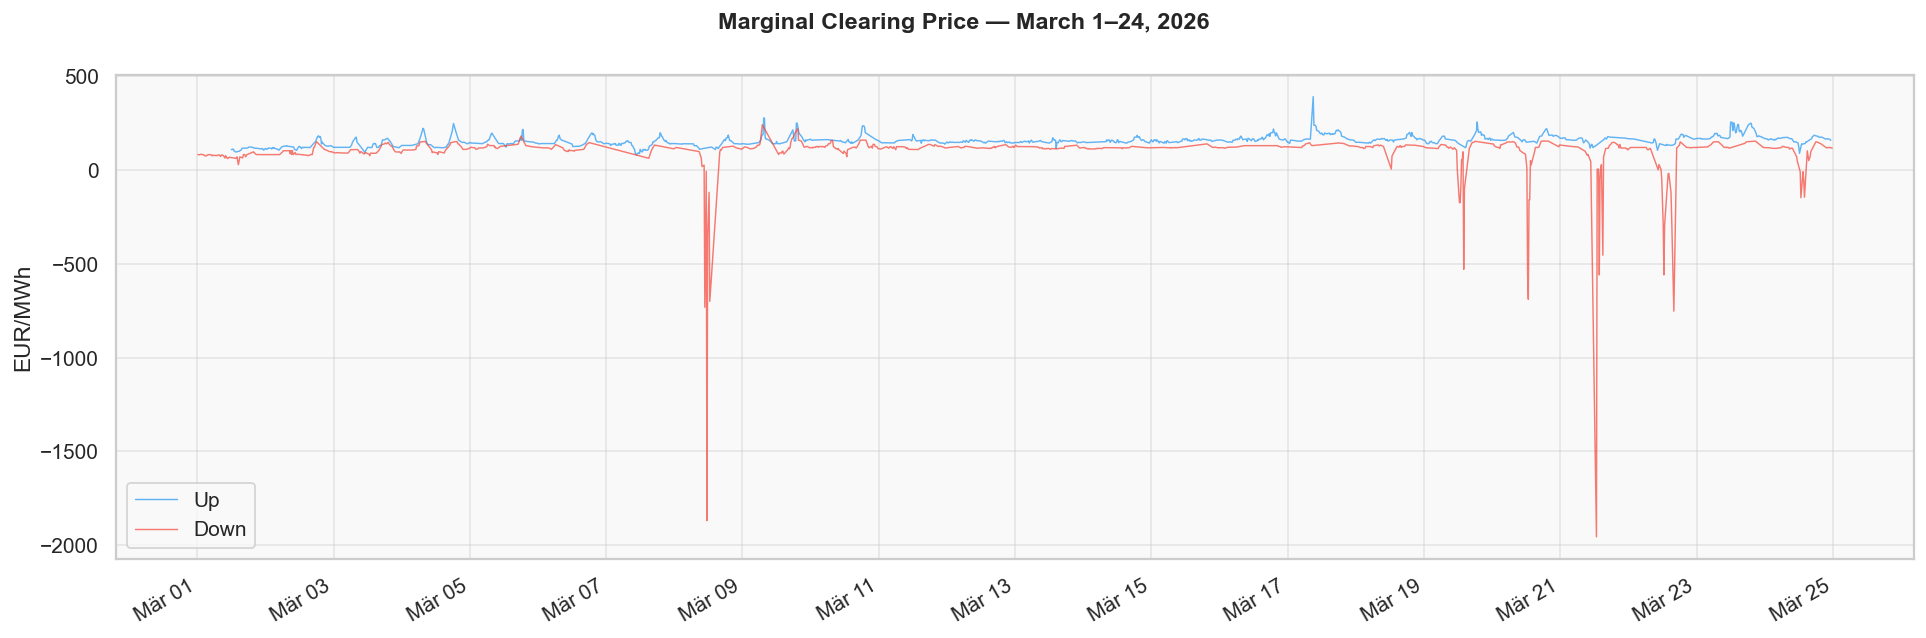

In [36]:
act = df[df['activated']].copy()

# Up:   TSO activates cheapest first → marginal = highest activated price
# Down: TSO activates highest first  → marginal = lowest activated price
marginal_up = (
    act[act['group'] == 'Up']
    .groupby('datetime')['price_eur']
    .max()
    .rename('marginal_price')
    .reset_index()
    .assign(group='Up')
)
marginal_down = (
    act[act['group'] == 'Down']
    .groupby('datetime')['price_eur']
    .min()
    .rename('marginal_price')
    .reset_index()
    .assign(group='Down')
)
marginal = pd.concat([marginal_up, marginal_down], ignore_index=True)

fig, ax = plt.subplots(figsize=(15, 5))
for grp in PRODUCT_ORDER:
    sub = marginal[marginal['group'] == grp]
    if not sub.empty:
        ax.plot(sub['datetime'], sub['marginal_price'],
                lw=0.8, alpha=0.7, color=PRODUCT_COLORS[grp], label=grp)

ax.set_ylabel('EUR/MWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Marginal Clearing Price — March 1–24, 2026', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6  Daily Offered vs. Called Volume

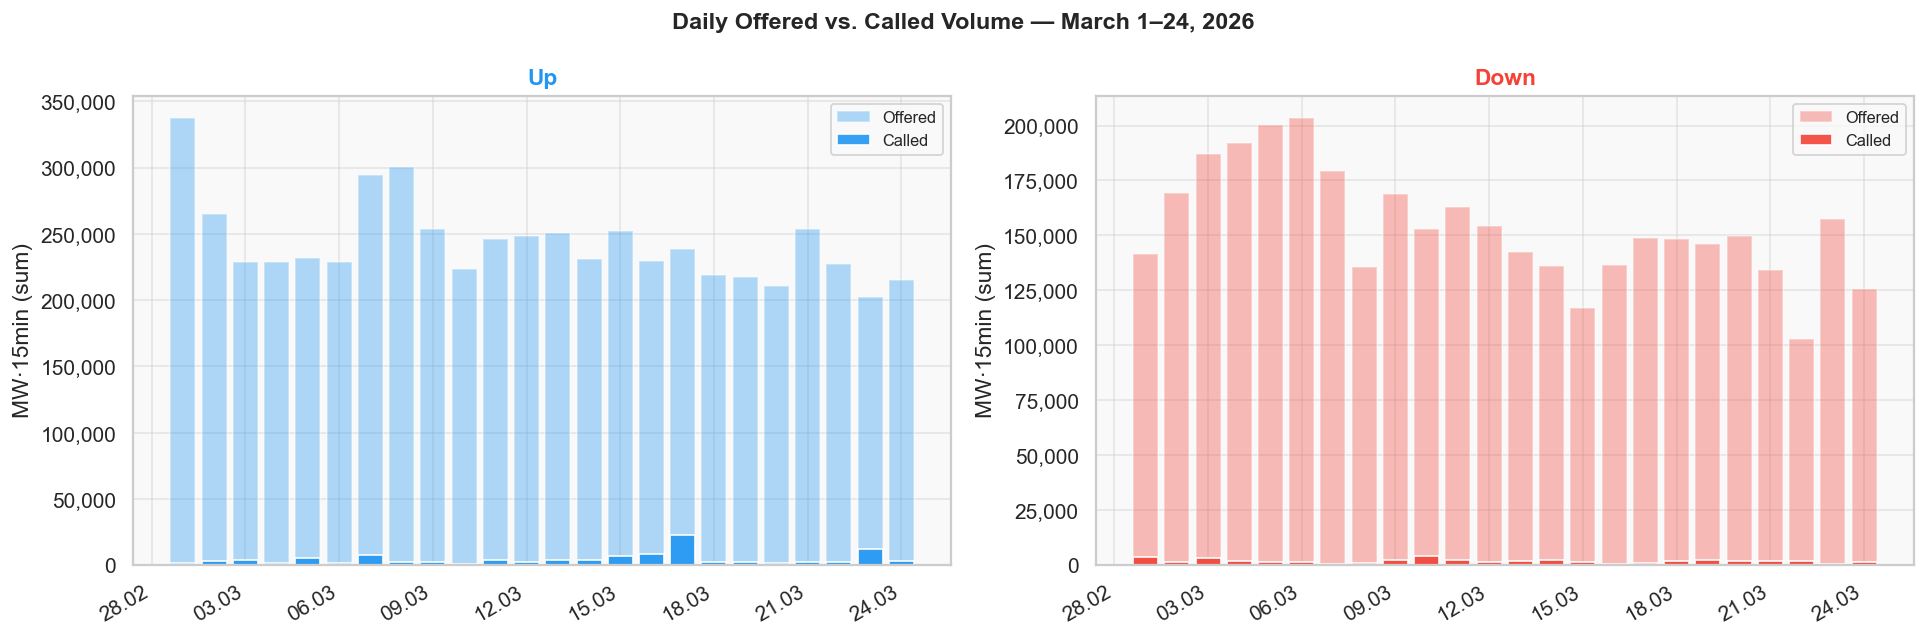

In [37]:
daily = (
    df.groupby(['date', 'group'])
    .agg(offered=('offered_mw', 'sum'), called=('called_mw', 'sum'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, grp in zip(axes, PRODUCT_ORDER):
    sub = daily[daily['group'] == grp]
    ax.bar(sub['date'], sub['offered'], color=PRODUCT_COLORS[grp], alpha=0.35,
           width=0.8, label='Offered')
    ax.bar(sub['date'], sub['called'], color=PRODUCT_COLORS[grp], alpha=0.9,
           width=0.8, label='Called')
    ax.set_title(grp, fontweight='bold', color=PRODUCT_COLORS[grp])
    ax.set_ylabel('MW·15min (sum)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Daily Offered vs. Called Volume — March 1–24, 2026',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7  Activation Rate & Hourly Patterns

What fraction of bid volume gets activated, and does it vary by hour of day?

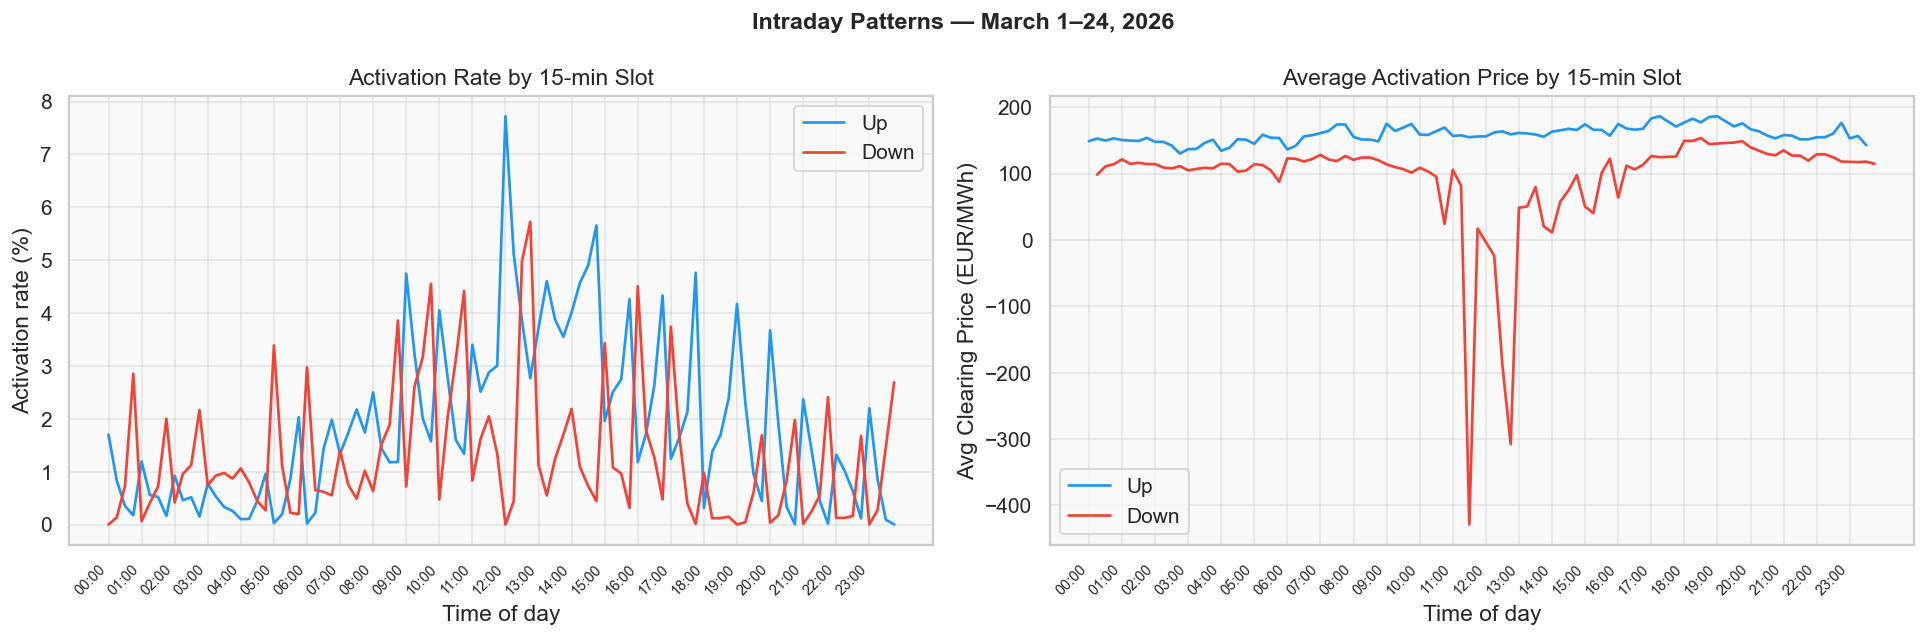

In [38]:
slot_labels = {s: f'{s//4:02d}:{(s%4)*15:02d}' for s in range(96)}
tick_slots  = range(0, 96, 4)  # one tick per hour

slot_vol = (
    df.groupby(['slot', 'group'])
    .agg(offered=('offered_mw', 'sum'), called=('called_mw', 'sum'))
    .reset_index()
)
slot_vol['act_rate'] = slot_vol['called'] / slot_vol['offered'] * 100

slot_price = (
    df[df['activated']]
    .groupby(['slot', 'group'])['price_eur']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for grp in PRODUCT_ORDER:
    sub = slot_vol[slot_vol['group'] == grp]
    ax.plot(sub['slot'], sub['act_rate'], color=PRODUCT_COLORS[grp], lw=1.5, label=grp)
ax.set_xticks(list(tick_slots))
ax.set_xticklabels([slot_labels[s] for s in tick_slots], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Time of day')
ax.set_ylabel('Activation rate (%)')
ax.set_title('Activation Rate by 15-min Slot')
ax.legend()

ax = axes[1]
for grp in PRODUCT_ORDER:
    sub = slot_price[slot_price['group'] == grp]
    ax.plot(sub['slot'], sub['price_eur'], color=PRODUCT_COLORS[grp], lw=1.5, label=grp)
ax.set_xticks(list(tick_slots))
ax.set_xticklabels([slot_labels[s] for s in tick_slots], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Time of day')
ax.set_ylabel('Avg Clearing Price (EUR/MWh)')
ax.set_title('Average Activation Price by 15-min Slot')
ax.legend()

fig.suptitle('Intraday Patterns — March 1–24, 2026', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

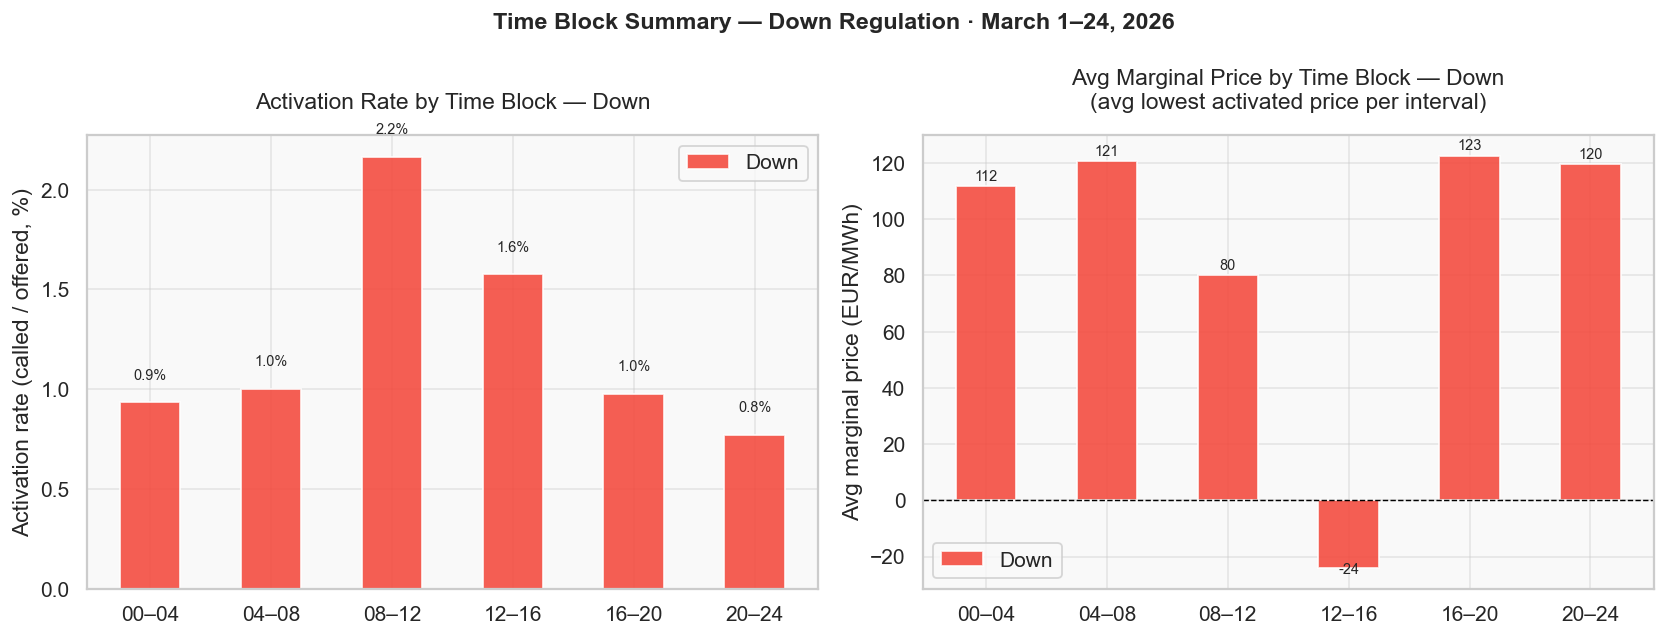

In [39]:
# Marginal price per interval: max activated for Up, min activated for Down
mp_up   = df[df['activated'] & (df['group'] == 'Up')].groupby('datetime')['price_eur'].max().reset_index().assign(group='Up')
mp_down = df[df['activated'] & (df['group'] == 'Down')].groupby('datetime')['price_eur'].min().reset_index().assign(group='Down')
marginal_per_interval = pd.concat([mp_up, mp_down], ignore_index=True)
marginal_per_interval['hour'] = marginal_per_interval['datetime'].dt.hour

block_stats = []
for lbl, h0, h1 in TIME_BLOCKS:
    sub = df[df['hour'].between(h0, h1)]
    mp  = marginal_per_interval[marginal_per_interval['hour'].between(h0, h1)]
    for grp in PRODUCT_ORDER:
        g = sub[sub['group'] == grp]
        block_stats.append({
            'block':              lbl,
            'group':              grp,
            'act_rate':           g['called_mw'].sum() / g['offered_mw'].sum() * 100,
            'avg_marginal_price': mp[mp['group'] == grp]['price_eur'].mean(),
        })
block_df = pd.DataFrame(block_stats)

x     = np.arange(len(TIME_BLOCKS))
width = 0.5
down  = block_df[block_df['group'] == 'Down']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: activation rate per block (Down only) ───────────────────────────────
ax = axes[0]
vals = down['act_rate'].values
bars = ax.bar(x, vals, width, color=PRODUCT_COLORS['Down'], alpha=0.85, label='Down')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([lbl for lbl, _, _ in TIME_BLOCKS])
ax.set_ylabel('Activation rate (called / offered, %)')
ax.set_title('Activation Rate by Time Block — Down', pad=15)
ax.legend()

# ── Right: avg marginal price per block (Down only) ───────────────────────────
ax = axes[1]
vals = down['avg_marginal_price'].values
bars = ax.bar(x, vals, width, color=PRODUCT_COLORS['Down'], alpha=0.85, label='Down')
for bar, v in zip(bars, vals):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (1 if v >= 0 else -3),
                f'{v:.0f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([lbl for lbl, _, _ in TIME_BLOCKS])
ax.set_ylabel('Avg marginal price (EUR/MWh)')
ax.set_title('Avg Marginal Price by Time Block — Down\n(avg lowest activated price per interval)', pad=15)
ax.legend()
ax.axhline(0, color='black', lw=0.8, ls='--')

fig.suptitle('Time Block Summary — Down Regulation · March 1–24, 2026', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9  Merit Order Curves

Average supply curve across all periods, showing cumulative offered capacity sorted by price.

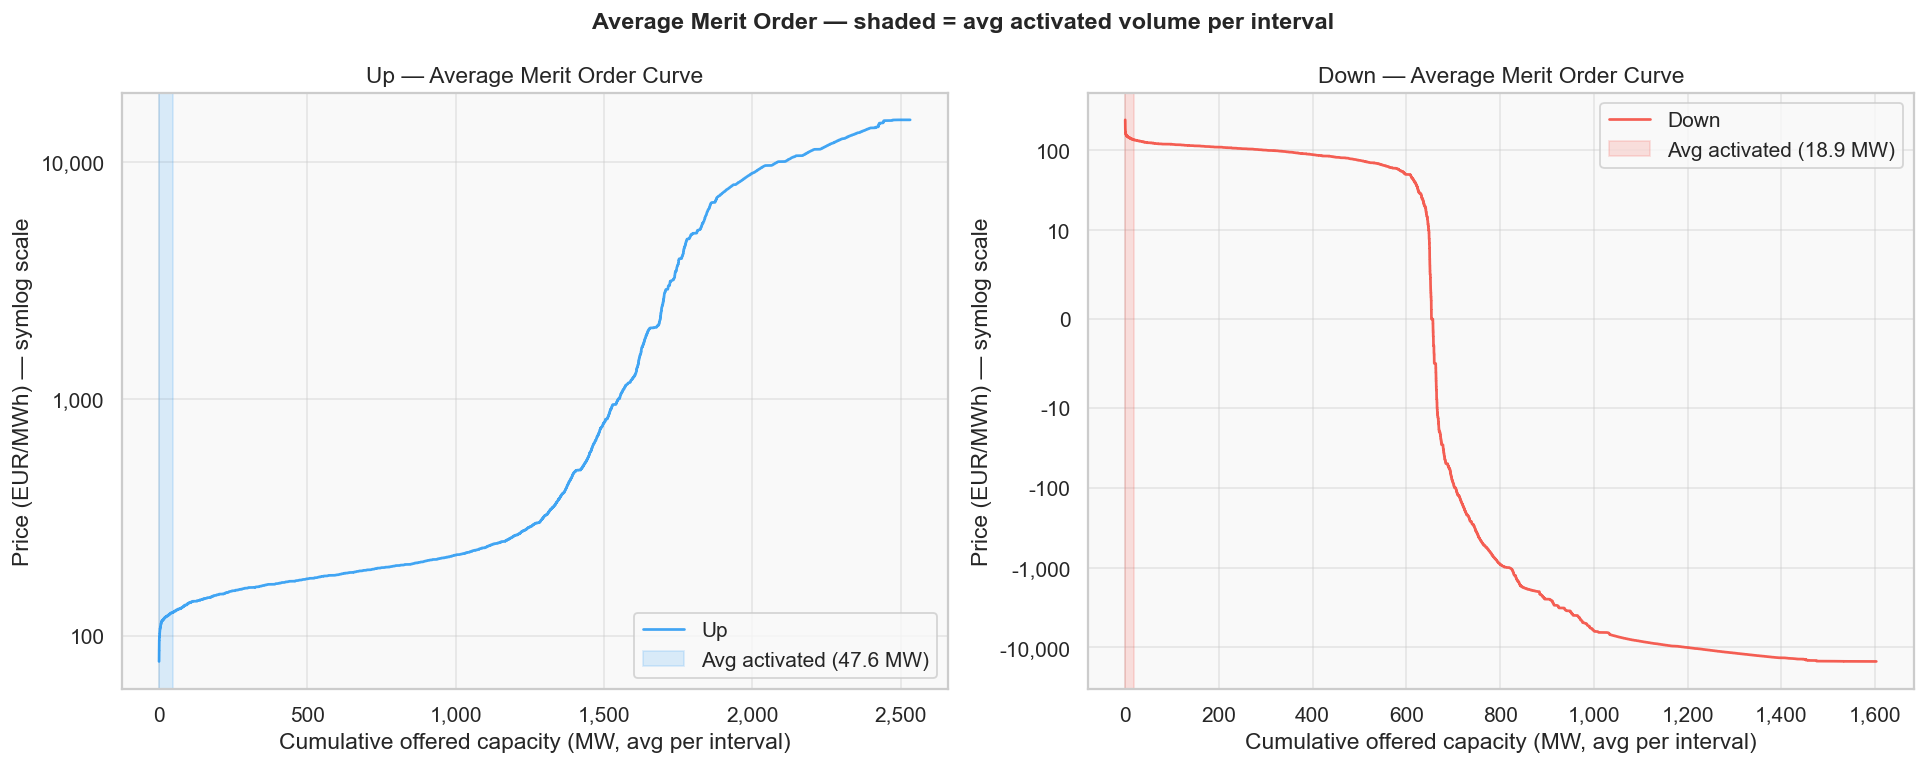

In [40]:
n_intervals   = df.groupby('group')['datetime'].nunique()
avg_called_mw = df.groupby('group')['called_mw'].sum() / n_intervals

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, grp in zip(axes, PRODUCT_ORDER):
    # Up: cheapest first (ascending); Down: most expensive first (descending)
    ascending = (grp == 'Up')
    sub   = df[df['group'] == grp].sort_values('price_eur', ascending=ascending)
    n_int = n_intervals.get(grp, 1)
    cum_mw = sub['offered_mw'].cumsum() / n_int

    ax.step(cum_mw, sub['price_eur'].values,
            color=PRODUCT_COLORS[grp], lw=1.5, alpha=0.85, label=grp)

    # Shade from 0 to average called MW per interval
    avg_vol = avg_called_mw.get(grp, 0)
    ax.axvspan(0, avg_vol, alpha=0.15, color=PRODUCT_COLORS[grp],
               label=f'Avg activated ({avg_vol:,.1f} MW)')

    ax.set_yscale('symlog', linthresh=10)
    ax.set_xlabel('Cumulative offered capacity (MW, avg per interval)')
    ax.set_ylabel('Price (EUR/MWh) — symlog scale')
    ax.set_title(f'{grp} — Average Merit Order Curve')
    ax.legend()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:,.0f}'))

fig.suptitle('Average Merit Order — shaded = avg activated volume per interval',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12  Weekly Patterns

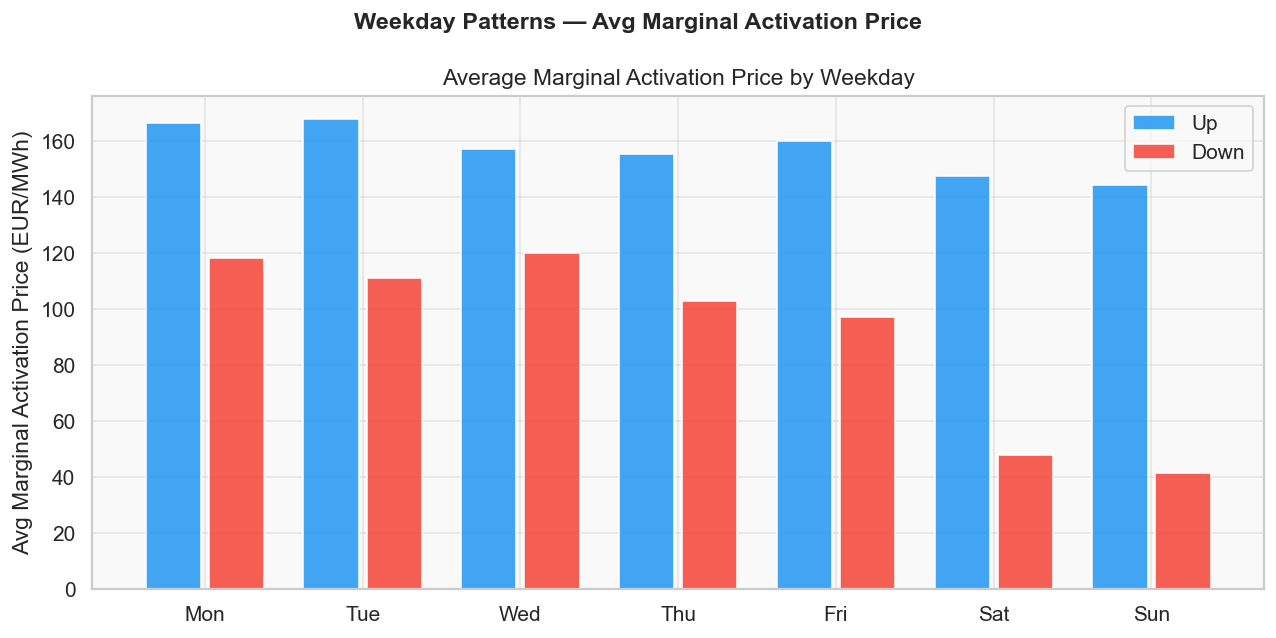

In [41]:
df['weekday'] = df['datetime'].dt.dayofweek
df['weekday_name'] = df['datetime'].dt.day_name()
WEEKDAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Marginal activation price per interval: max for Up (cheapest-first stack), min for Down
act = df[df['activated']].copy()
mp_up   = act[act['group'] == 'Up'].groupby('datetime')['price_eur'].max().reset_index().assign(group='Up')
mp_down = act[act['group'] == 'Down'].groupby('datetime')['price_eur'].min().reset_index().assign(group='Down')
marginal = pd.concat([mp_up, mp_down], ignore_index=True)
marginal['weekday_name'] = marginal['datetime'].dt.day_name()

weekly = (
    marginal
    .groupby(['weekday_name', 'group'])['price_eur']
    .mean()
    .reset_index()
)
weekly['weekday_name'] = pd.Categorical(weekly['weekday_name'],
                                         categories=WEEKDAY_ORDER, ordered=True)
weekly = weekly.sort_values('weekday_name')

fig, ax = plt.subplots(figsize=(10, 5))
for i, grp in enumerate(PRODUCT_ORDER):
    sub = weekly[weekly['group'] == grp]
    vals = [sub.loc[sub['weekday_name'] == d, 'price_eur'].values[0]
            if d in sub['weekday_name'].values else np.nan
            for d in WEEKDAY_ORDER]
    ax.bar(np.arange(7) + i * 0.4 - 0.2, vals,
           width=0.35, color=PRODUCT_COLORS[grp], alpha=0.85, label=grp)

ax.set_xticks(np.arange(7))
ax.set_xticklabels([d[:3] for d in WEEKDAY_ORDER])
ax.set_ylabel('Avg Marginal Activation Price (EUR/MWh)')
ax.set_title('Average Marginal Activation Price by Weekday')
ax.legend()

fig.suptitle('Weekday Patterns \u2014 Avg Marginal Activation Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13  Bid Size Distribution

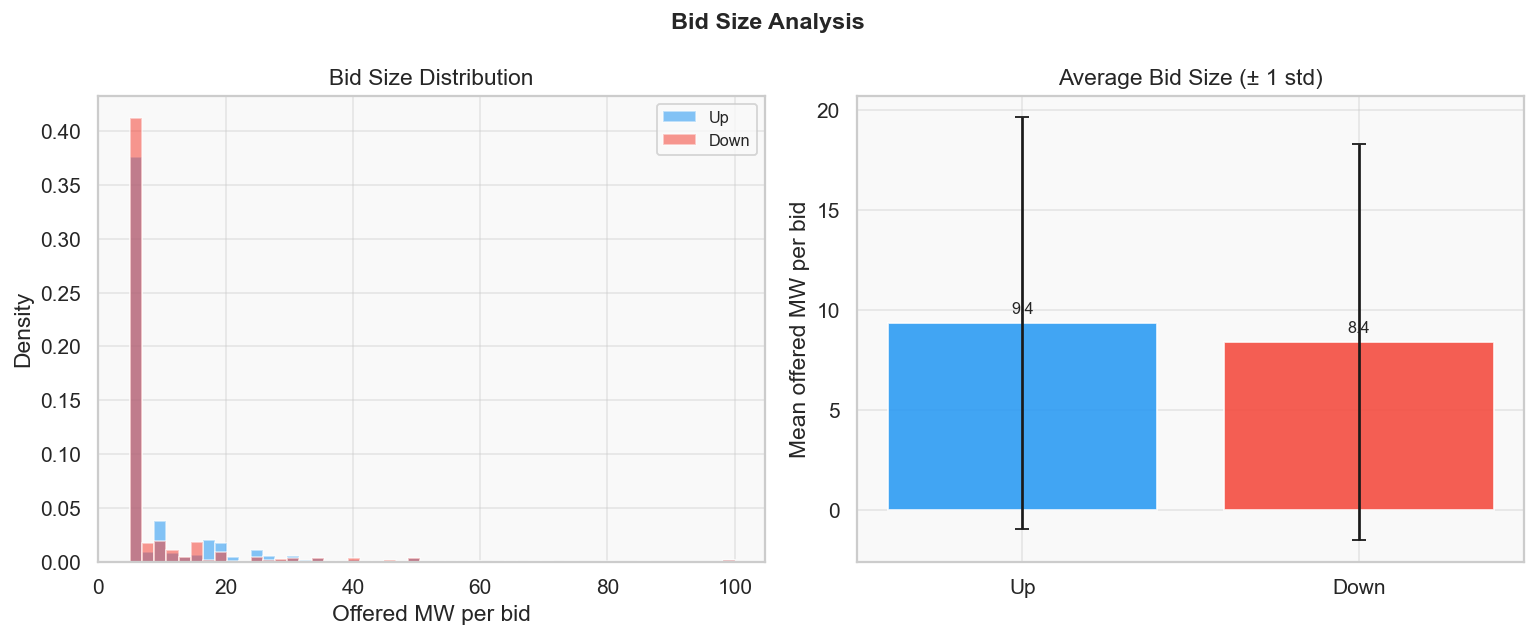

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for grp in PRODUCT_ORDER:
    bids = df.loc[df['group'] == grp, 'offered_mw']
    ax.hist(bids, bins=50, alpha=0.55, color=PRODUCT_COLORS[grp],
            label=grp, density=True)
ax.set_xlabel('Offered MW per bid')
ax.set_ylabel('Density')
ax.set_title('Bid Size Distribution')
ax.legend(fontsize=9)
ax.set_xlim(0)

ax = axes[1]
bid_size = df.groupby('group')['offered_mw'].describe().reindex(PRODUCT_ORDER)
x = np.arange(len(PRODUCT_ORDER))
bars = ax.bar(x, bid_size['mean'], yerr=bid_size['std'], capsize=4,
              color=[PRODUCT_COLORS[g] for g in PRODUCT_ORDER], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(PRODUCT_ORDER)
ax.set_ylabel('Mean offered MW per bid')
ax.set_title('Average Bid Size (± 1 std)')
for bar, val in zip(bars, bid_size['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Bid Size Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 14  Key Findings

> Run the cells above to populate these findings automatically.

In [43]:
print('=' * 60)
print('KEY FINDINGS — TRE Bidding Analysis, March 1–24, 2026')
print('=' * 60)

for grp in PRODUCT_ORDER:
    sub = df[df['group'] == grp]
    act = sub[sub['activated']]
    act_rate = len(act) / len(sub) * 100
    vol_rate = sub['called_mw'].sum() / sub['offered_mw'].sum() * 100
    print(f"\n{grp}")
    print(f"  Bids: {len(sub):>8,}   Activated: {len(act):>6,}  ({act_rate:.1f}%)")
    print(f"  Volume offered: {sub['offered_mw'].sum():>10,.0f} MW·slot"
          f"  Called: {sub['called_mw'].sum():>8,.0f} ({vol_rate:.1f}%)")
    if not act.empty:
        print(f"  Activation price — median: {act['price_eur'].median():.1f}"
              f"  mean: {act['price_eur'].mean():.1f}"
              f"  max: {act['price_eur'].max():.1f}  EUR/MWh")

print('\n' + '=' * 60)

KEY FINDINGS — TRE Bidding Analysis, March 1–24, 2026

Up
  Bids:  623,530   Activated:  8,072  (1.3%)
  Volume offered:  5,834,305 MW·slot  Called:  109,646 (1.9%)
  Activation price — median: 160.0  mean: 162.4  max: 391.0  EUR/MWh

Down
  Bids:  439,528   Activated:  2,918  (0.7%)
  Volume offered:  3,692,889 MW·slot  Called:   43,585 (1.2%)
  Activation price — median: 117.3  mean: 67.1  max: 241.5  EUR/MWh

